In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------


# How much solvent does it take to pull acetone out of water? (Illustration 11.2-8)

This notebook works **Illustration 11.2-8** — one contact of 3 kg of methyl isobutyl
ketone (MIK) with 1 kg of a 60 wt % acetone / 40 wt % water mixture — and it draws the
chapter's three views of this system: **Figure 11.2-8**, the triangular diagram the
illustration is solved on; **Figure 11.2-9**, the acetone distribution between the two
layers; and **Figure 11.2-10**, the same coexistence data on rectangular axes. One data
set, three projections, and they are drawn from the same arrays so they cannot disagree.

**Why a triangular diagram at all.** Three species have two independent compositions, so
a ternary mixture needs two dimensions and no more. The triangle is the natural way to
spend them: every point inside has three coordinates that sum to one, and the constraint
is built into the geometry instead of being carried around as an equation. Everything
the illustration does — locating a feed, reading a tie line, splitting an amount — is
then a ruler-and-eye construction on that picture.

**Why this notebook exists.** The only tool the book has offered for making a
ternary diagram was Aspen Plus — the chapter's own footnote 12 says so, and points at a
file on a publisher's website. A triangular diagram is about a hundred lines of geometry.
It should not require a license.

**What is measured and what is not.** The coexistence dome is real data, and it is
printed in the chapter itself: sixteen compositions from D. F. Othmer, R. E. White and
E. Trueger, *Ind. Eng. Chem.* **33**, 1240 (1941). The *tie lines* are a different
matter, and the notebook is careful about the difference — see the section that asks
where the illustration's tie line came from.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst  
August 2026


In [2]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator, UnivariateSpline

from thermo.charts import use_book_style
from thermo import ternary
from thermo.lle import mix_streams, tie_line_split

use_book_style()

# Liquid-liquid coexistence compositions for methyl isobutyl ketone (MIK) + acetone +
# water at 298.15 K, in weight percent. D. F. Othmer, R. E. White and E. Trueger,
# Ind. Eng. Chem. 33, 1240 (1941) -- the reference SIS gives in footnote 13, and the
# same sixteen points the chapter prints in the table below Fig. 11.2-8.
#
# The chapter prints them two-up, eight rows of six columns. They are transcribed here
# as one list of sixteen because that is what they are: points on a single curve, in no
# particular order. Ordering them along the curve is done below, by geometry.
OTHMER_1941 = np.array([
    # MIK   acetone  water            MIK   acetone  water
    [93.2,   4.60,   2.33], [27.4,  48.4,  24.1],
    [77.3,  18.95,   3.86], [20.1,  46.3,  33.5],
    [71.0,  24.4,    4.66], [ 2.12,  3.73, 94.2],
    [65.5,  28.9,    5.53], [ 3.23, 20.9,  75.8],
    [54.7,  37.6,    7.82], [ 5.01, 30.9,  64.2],
    [46.2,  43.2,   10.7 ], [12.4,  42.7,  45.0],
    [38.3,  47.0,   14.8 ], [20.5,  46.6,  32.8],
    [32.8,  48.3,   18.8 ], [25.9,  50.7,  23.4],
])
MIK, ACE, WAT = 0, 1, 2

print(f"  {len(OTHMER_1941)} coexistence compositions, MIK + acetone + water at 298.15 K")

  16 coexistence compositions, MIK + acetone + water at 298.15 K


## First: does the table survive transcription?

**A composition table carries its own check, and it costs nothing to run.** Three
weight percents that describe one phase must add to 100. Nothing external is needed —
no second source, no model — so a digit lost between the page and the keyboard shows up
immediately.

Run it every time, not only here. The failure it catches is silent: a
transposed digit still plots, still looks like a phase boundary, and still lets every
calculation downstream run to completion.

In [3]:
sums = OTHMER_1941.sum(axis=1)
worst = np.argmax(np.abs(sums - 100))

print(f"  closure  min {sums.min():.2f}   max {sums.max():.2f}   worst |sum - 100| = "
      f"{abs(sums[worst] - 100):.2f} wt %")
print(f"  worst point: MIK {OTHMER_1941[worst, MIK]}, acetone {OTHMER_1941[worst, ACE]}, "
      f"water {OTHMER_1941[worst, WAT]}")
assert np.all(np.abs(sums - 100) < 0.5), "a composition does not close -- check the transcription"

# Normalize onto the simplex before anything is drawn, so the 0.13 wt % of rounding
# does not leak into the geometry.
BINODAL = OTHMER_1941 / sums[:, None]

  closure  min 99.90   max 100.13   worst |sum - 100| = 0.13 wt %
  worst point: MIK 93.2, acetone 4.6, water 2.33


## Ordering the points, and drawing a curve through them

The sixteen points are a *set*, not a path — the chapter prints them two-up, which is a
page-fitting decision. To draw a curve they have to be ordered first.

**The obvious method fails, and it fails exactly where it matters.** A nearest-neighbor
walk hops across the top of the dome, because near the plait point two points on *opposite*
branches are closer to each other than to their own neighbors.

**MIK content orders it.** It falls from 93.2 wt % to 2.12 strictly, at every one of the
sixteen, so the dome is single-valued in it and sorting on it traverses the curve exactly
once. The cell below asserts that rather than assuming it.

**That still leaves a kink, and the kink is real.** Joining the ordered points directly
turns through **77° and 104°** at the two points either side of the crest, where every other
vertex on the curve turns by a few degrees.

**Two features of the data cause it, and both are near the top of the dome.**

1. **One errant point.** 25.9 % MIK / 50.7 % acetone / 23.4 % water sits about **2.2 wt %
   above a smooth curve through the other fifteen**, which all fall within 1.0.

   **It is Othmer's own number, and that was checked against the printed page rather than
   against a text layer** — a 1941 journal scan is OCR, and OCR misreads digits. Rendered at
   600 dpi, the last row of Table III reads 25.9 / 50.7 / 23.4 unambiguously, and the whole
   column matches. The chapter reprints it identically, and it closes to 100.0 exactly.

   **It is also not a random point in the list.** Othmer's column runs down the MIK-rich
   branch (93.2 → 20.1 wt % MIK) and then back up the water-rich branch (2.12 → 25.9), so
   this is the *last determination on the water-rich branch* — the closest of the sixteen to
   the plait point, which is exactly where the paper says the method is weakest.
2. **One near-duplicate.** 20.1 / 46.3 / 33.5 and 20.5 / 46.6 / 32.8 are the same composition
   to within 0.4 wt %, so the fit is pinned twice in one place while its neighbors are 5 to 16
   wt % apart. A doubled point next to an errant one is what bends a spline.

**The paper says where to expect exactly this.** Points near the plait point are the
hardest to measure — *"it is difficult to determine exactly points near the plait point
because of the little difference between composition and density of the two phases"* — and
this point is the closest of the sixteen to it. So the binodal is drawn as a smooth fit
through the measurements rather than a curve forced through every one of them, and all
sixteen points are plotted so the scatter stays visible.


In [4]:
order = np.argsort(-BINODAL[:, MIK])          # MIK-rich end first
ordered = BINODAL[order]

# The check that licenses the sort: MIK must be single valued along the curve.
assert np.all(np.diff(ordered[:, MIK]) < 0), "MIK is not monotone -- sort by branch instead"

# thermo.ternary takes (top, left, right): acetone at the apex, MIK left, water right.
curve = ordered[:, [ACE, MIK, WAT]]

# --- the drawn binodal: a SMOOTHING fit, not an interpolation -------------------
# Acetone as a function of MIK content, with water by difference so every point on the
# drawn curve closes to 1 exactly.
#
# s = 8 (in wt %^2), and the value is chosen by CURVATURE, not by residual. At s = 5 the
# fit is closer to the data -- rms 0.56 wt % against 0.71 -- and it is the wrong curve: the
# extra smoothness admits a sixth knot, the sixth knot lands near the crest, and the drawn
# curve carries a curvature spike 6x its own median there. That spike is the discontinuity
# a reader sees at the top of the dome. At s = 8 the spline has five knots and the peak
# curvature falls to 2x the median, which is what a smooth dome has anyway -- an arc is
# most sharply curved at its crest.
#
# Two features of the data drive it. The points are spaced 0.4 to 15.9 wt % apart in MIK,
# and the closest pair -- 20.1 and 20.5 wt % MIK, 0.3 wt % apart in acetone -- is a near
# duplicate that pins the fit twice in one place. Weighting by spacing fixes the spike just
# as well (rms 0.78, curvature 2.0x); the knot count is the simpler lever and is left as the
# one in play.
_m, _a = 100 * ordered[::-1, MIK], 100 * ordered[::-1, ACE]
_fit = UnivariateSpline(_m, _a, k=3, s=8.0)
_grid = np.linspace(_m.min(), _m.max(), 400)
_ace = _fit(_grid)
smooth = np.column_stack([_ace, _grid, 100 - _grid - _ace]) / 100

resid = _a - _fit(_m)
worst = int(np.argmax(np.abs(resid)))
print(f"  fit residual: rms {np.sqrt((resid**2).mean()):.2f} wt %, "
      f"worst {resid[worst]:+.2f} at MIK {_m[worst]:.1f} / acetone {_a[worst]:.1f}")
print(f"  every other point is within {np.sort(np.abs(resid))[-2]:.2f} wt % of the curve")
print(f"  spline knots: {len(_fit.get_knots())}")

# The crest -- the richest the two-phase region ever gets in acetone.
CREST = smooth[np.argmax(smooth[:, 0])]
print(f"  crest of the dome: {100*CREST[1]:.1f} MIK / {100*CREST[0]:.1f} acetone / "
      f"{100*CREST[2]:.1f} water")


  fit residual: rms 0.71 wt %, worst +2.19 at MIK 25.9 / acetone 50.7
  every other point is within 1.02 wt % of the curve
  spline knots: 5
  crest of the dome: 28.6 MIK / 48.6 acetone / 22.8 water


## The tie lines, from Othmer's Table VII

**The tie lines are measured after all, and they are in the paper the chapter cites.**
Othmer, White and Trueger's **Table VII** gives, for methyl isobutyl ketone as solvent, the
weight percent acetone in the *solvent* layer beside the weight percent in the *water* layer
for five conjugate pairs. With the coexistence curve already in hand, a pair of acetone
contents fixes a whole tie line: each end is the point on its own branch of the dome with that
much acetone in it.

**How they were measured matters, and the paper is explicit.** Acetone was determined by
the Messinger method in every acetone system *except this one* — *"system 25, where it could
not be so determined in the presence of methyl isobutyl ketone."* These five pairs come from
the **synthetic density method** instead: weigh the layers, measure the density of one, and
compute the compositions. That is why Table VII is a distribution-*density* table and why MIK
is absent from Table VI, where the analytically determined systems are.

**The check that the transcription is right is thermodynamic, not arithmetic.** Tie lines in
a two-phase region cannot cross — two crossing tie lines would put one composition in
equilibrium with two different partners. The cell below tests that.


In [5]:
# Acetone distribution between the two phases: wt % acetone in the MIK layer beside
# wt % in the coexisting water layer. Five conjugate pairs -- five tie lines.
#
# THE CHAPTER PRINTS THIS TABLE TOO, on the same page as the binodal, and it is
# Othmer, White and Trueger's Table VII ("Distribution-Density Data, 25-26 C",
# methyl isobutyl ketone as solvent) reprinted exactly. Both were checked against
# the paper: all sixteen binodal points and all five pairs agree digit for digit.
TABLE_VII = np.array([[10.66,  5.58],
                      [18.0,  11.83],
                      [25.5,  15.35],
                      [30.5,  20.6 ],
                      [35.3,  23.8 ]]) / 100

# Split the dome at its acetone maximum: everything up to it is the MIK-rich branch,
# everything past it the water-rich branch. Each branch is single valued in acetone, so
# an acetone content picks out one composition on it.
# Split the DRAWN curve at its crest: everything richer in MIK is one branch,
# everything poorer the other. Each branch is single valued in acetone, so an acetone
# content picks out one composition on it -- and the ends then sit on the curve the
# reader sees rather than on a separate interpolation.
# Split by MIK CONTENT, not by array position: `smooth` is generated in ascending
# MIK, so slicing it at the crest by index puts the water-rich half first and silently
# swaps the two ends of every tie line.
_apex = int(np.argmax(smooth[:, 0]))
_mik_side = smooth[:, 1] >= smooth[_apex, 1]
BRANCH_MIK, BRANCH_WATER = smooth[_mik_side], smooth[~_mik_side]

def end_at_acetone(branch, a):
    """The composition on `branch` holding acetone weight fraction `a`."""
    o = np.argsort(branch[:, 0])
    return np.array([PchipInterpolator(branch[o, 0], branch[o, k])(a) for k in range(3)])

TIES = [(end_at_acetone(BRANCH_MIK, aS), end_at_acetone(BRANCH_WATER, aW))
        for aS, aW in TABLE_VII]

print(f"  {'MIK-rich end':>26s}   {'water-rich end':>26s}")
for I, II in TIES:
    print(f"   {100*I[1]:5.1f} MIK {100*I[0]:5.2f} A {100*I[2]:5.2f} W "
          f"    {100*II[1]:5.2f} MIK {100*II[0]:5.2f} A {100*II[2]:5.1f} W")

# Tie lines may not cross: one composition cannot be in equilibrium with two partners.
def _crosses(t, u):
    (a, b), (c, d) = ternary.to_xy(np.array(t)), ternary.to_xy(np.array(u))
    turn = lambda P, Q, R: np.sign((Q[0]-P[0])*(R[1]-P[1]) - (Q[1]-P[1])*(R[0]-P[0]))
    return turn(a, b, c) != turn(a, b, d) and turn(c, d, a) != turn(c, d, b)

bad = [(i, j) for i in range(len(TIES)) for j in range(i+1, len(TIES))
       if _crosses(TIES[i], TIES[j])]
assert not bad, f"tie lines {bad} cross -- re-read Table VII"
print("\n  no two tie lines cross: the set is thermodynamically admissible")


                MIK-rich end               water-rich end
    86.0 MIK 10.66 A  3.36 W      2.19 MIK  5.58 A  92.2 W
    77.8 MIK 18.00 A  4.20 W      2.53 MIK 11.83 A  85.6 W
    69.6 MIK 25.50 A  4.93 W      2.76 MIK 15.35 A  81.9 W
    63.9 MIK 30.50 A  5.60 W      3.19 MIK 20.60 A  76.2 W
    58.1 MIK 35.30 A  6.61 W      3.56 MIK 23.80 A  72.6 W

  no two tie lines cross: the set is thermodynamically admissible


## Figure 11.2-9 — how the acetone divides between the two layers

Those five pairs are the whole of Figure 11.2-9, and the chapter uses that figure to
build the tie lines in Fig. 11.2-8: pick an acetone content for the water layer, read the
coexisting content in the MIK layer off this curve, then find each of the two on its own
branch of the dome.

**A curve through five scattered points is a decision, and this one moves a number the
chapter prints.** The five distribution ratios — acetone in the MIK layer divided by
acetone in the water layer — are 1.91, 1.52, 1.66, 1.48 and 1.48. The first is the most
dilute pair and it sits above the other four, so a smooth curve through all five does not
pass through it.

| how the curve is drawn | reads at 5 wt % in the water layer |
|---|---|
| interpolated through all five points | 9.8 wt % |
| the first pair alone, as a straight ratio | 9.6 |
| **least squares, distribution ratio linear in concentration** | **8.7** |
| the other four points, extrapolated back | 8.4 |

The chapter's step 2 says *"the acetone composition in the MIK-rich phase in equilibrium
with 5 wt % acetone in the water-rich phase is found from Fig. 11.2-9 to be approximately
10 wt %"* — the top of that range, which is the value obtained by drawing the curve
through the most dilute pair.

This figure takes the least-squares fit, $w^{\rm MIK} = w^{\rm water}(1.81 - 1.44\,
w^{\rm water})$, for the same reason Fig. 11.2-8 is a fit: Othmer states that none of his
data were smoothed, so the scatter is measurement scatter, and a curve forced through it
turns the scatter into structure. All five points are plotted, 1.4 wt % from the curve at
the worst of them.

**Below 5.58 wt % nothing was measured.** The curve reaches the origin because a phase
with no acetone in it coexists with a phase with no acetone in it — that point is exact,
not measured — but between the origin and the first pair the shape of the curve is the
fit's, and Illustration 11.2-9 reads a second-stage tie line at 3.0 wt %, inside that
stretch.


  K = 1.81 -1.44 w    (falls from 1.81 at infinite dilution to 1.47 at the richest pair)
  residual: rms 0.98 wt %, worst 1.40 wt %

  at 5 wt % in the water layer this curve reads 8.7 wt % in the MIK layer
  SIS's step 2, reading the printed figure: 'approximately 10 wt %'
  through all five points instead: 9.8 wt %



  wrote pdf/Figure_11.2-9.pdf


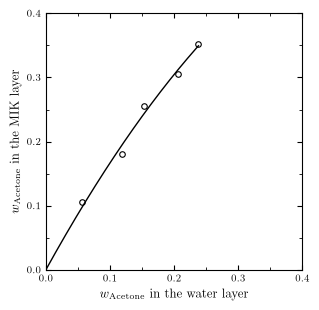

In [6]:
# --- Print art: Figure 11.2-9 ----------------------------------------------
#   pdf/Figure_11.2-9.pdf -> deliverables/figures/print-bw/ch11/c11f012.pdf
#
# Othmer's Table VII, plotted the way the chapter plots it: acetone in the MIK layer
# against acetone in the water layer, both as weight fractions, on 0-0.4 axes.
#
# The drawn curve is a least-squares fit of the DISTRIBUTION RATIO, K = w_MIK / w_water,
# linear in concentration -- so w_MIK = w_water (K0 + K1 w_water), which is a quadratic
# through the origin. Three properties make it the fit to use here rather than a spline:
#
#   1. It passes through the origin exactly, which is thermodynamics and not data.
#   2. K stays finite as the solution becomes dilute. A power law or a smoothing spline
#      fits these five points as well or better and sends K to 17-80 at the origin,
#      which would draw a hook in the dilute corner where two of the chapter's three
#      read-off tie lines live.
#   3. Two parameters cannot put an inflection between measured points, so scatter
#      cannot become curvature -- the failure that made Fig. 11.2-8 a fit as well.
W_WATER, W_MIK = TABLE_VII[:, 1], TABLE_VII[:, 0]

K0, K1 = np.linalg.lstsq(np.column_stack([W_WATER, W_WATER**2]), W_MIK, rcond=None)[0]
distribution = lambda w: w * (K0 + K1 * w)

_r = distribution(W_WATER) - W_MIK
print(f"  K = {K0:.2f} {K1:+.2f} w    (falls from {K0:.2f} at infinite dilution to "
      f"{K0 + K1 * W_WATER[-1]:.2f} at the richest pair)")
print(f"  residual: rms {100*np.sqrt((_r**2).mean()):.2f} wt %, "
      f"worst {100*np.abs(_r).max():.2f} wt %")

# Three gates on the drawn curve, all of them physics rather than taste.
_w = np.linspace(0, W_WATER.max(), 400)
assert np.all(np.diff(distribution(_w)) > 0), "the distribution curve is not monotone"
assert np.all(distribution(_w[1:]) > _w[1:]), "acetone must be richer in the MIK layer"
assert np.abs(_r).max() < 0.015, "the fit misses a measured pair by more than 1.5 wt %"

print(f"\n  at 5 wt % in the water layer this curve reads "
      f"{100*distribution(0.05):.1f} wt % in the MIK layer")
print(f"  SIS's step 2, reading the printed figure: 'approximately 10 wt %'")
print(f"  through all five points instead: "
      f"{100*PchipInterpolator(np.r_[0, W_WATER], np.r_[0, W_MIK])(0.05):.1f} wt %")

fig9, ax9 = plt.subplots(figsize=(3.4, 3.2))
ax9.plot(_w, distribution(_w), "-", color="k", lw=1.0)
ax9.plot(W_WATER, W_MIK, "o", color="k", ms=4, mfc="none", mew=0.8)
ax9.set_xlim(0, 0.4)
ax9.set_ylim(0, 0.4)
ax9.set_xticks(np.arange(0, 0.41, 0.1)); ax9.set_xticks(np.arange(0, 0.41, 0.05), minor=True)
ax9.set_yticks(np.arange(0, 0.41, 0.1)); ax9.set_yticks(np.arange(0, 0.41, 0.05), minor=True)
ax9.set_xlabel(r"$w_{\mathrm{Acetone}}$ in the water layer", size=9)
ax9.set_ylabel(r"$w_{\mathrm{Acetone}}$ in the MIK layer", size=9)
ax9.tick_params(labelsize=7, direction="in", which="both", top=True, right=True)
ax9.set_aspect("equal")

os.makedirs("pdf", exist_ok=True)
fig9.tight_layout()
fig9.savefig("pdf/Figure_11.2-9.pdf", dpi=300, bbox_inches="tight")
print("\n  wrote pdf/Figure_11.2-9.pdf")


## Where is the plait point?

The chapter's text needs one — *"the plait point of the mixture … is indicated by the point
labeled **P** in the figure"* — and it is the one composition on this diagram that nobody
measured. The plait point is where a tie line shrinks to nothing and the two phases become
one, so it cannot be titrated for directly; it has to be inferred from the tie lines that
*were* measured.

**Putting P at the crest of the dome is wrong, and the tie lines show it.** They are not
horizontal — acetone is always richer in the MIK phase — so their two ends do not climb the
dome at the same rate. Following each end's position *along the curve* and asking where the
two would meet is the construction that answers the question, and it does not land at the top.

**It is a long extrapolation and the notebook does not hide it.** The five tie lines cover
only about half the arc between the ends of the dome, and the answer sits roughly six tie
lines past the last measured one. Three different fits are run below; their spread is the
honest uncertainty on P.


In [7]:
# Position of every tie-line end ALONG the drawn curve, 0 at the water corner and 1 at
# the MIK corner. Arc length is the right coordinate here and acetone is not: acetone
# turns over at the crest, so it cannot order points near the plait point.
_xy = ternary.to_xy(smooth)
_s = np.concatenate([[0], np.cumsum(np.hypot(*np.diff(_xy, axis=0).T))])
ARC = _s / _s[-1]
_crest_i = int(np.argmax(smooth[:, 0]))

def arc_at_acetone(side, a):
    sel = smooth[:, 1] >= smooth[_crest_i, 1] if side == "mik" else smooth[:, 1] <= smooth[_crest_i, 1]
    aa, ss = smooth[sel, 0], ARC[sel]
    k = np.argsort(aa)
    return np.interp(a, aa[k], ss[k])

s_mik = np.array([arc_at_acetone("mik", a) for a in TABLE_VII[:, 0]])
s_wat = np.array([arc_at_acetone("wat", a) for a in TABLE_VII[:, 1]])

print(f"  crest of the dome sits at arc {ARC[_crest_i]:.3f}")
print(f"  {'tie line':>18s} {'MIK end':>9s} {'water end':>10s} {'gap':>7s}")
for (aM, aW), x, y in zip(100 * TABLE_VII, s_mik, s_wat):
    print(f"   acetone {aM:5.2f}/{aW:5.2f} {x:9.3f} {y:10.3f} {x - y:7.3f}")

# Each end moves nearly linearly with tie-line number; solve for where they coincide.
n = np.arange(len(TABLE_VII))
def meet(sl):
    pm, pw = np.polyfit(n[sl], s_mik[sl], 1), np.polyfit(n[sl], s_wat[sl], 1)
    t = (pw[1] - pm[1]) / (pm[0] - pw[0])
    return t, np.polyval(pm, t)

print("\n  extrapolating the two ends to where they meet:")
ests = {}
for name, sl in (("all five", slice(0, 5)), ("last three", slice(2, 5)), ("last two", slice(3, 5))):
    t, sp = meet(sl)
    i = int(np.argmin(np.abs(ARC - sp)))
    ests[name] = smooth[i]
    print(f"    {name:11s} {t - 4:.1f} tie lines past the last, arc {sp:.3f}  ->  "
          f"{100*smooth[i,1]:5.1f} MIK / {100*smooth[i,0]:5.1f} acetone / {100*smooth[i,2]:5.1f} water")

PLAIT = ests["all five"]
spread = np.array(list(ests.values()))
print(f"\n  P is taken as {100*PLAIT[1]:.0f} MIK / {100*PLAIT[0]:.0f} acetone / "
      f"{100*PLAIT[2]:.0f} water, and the three fits span "
      f"{100*spread[:,1].min():.0f}-{100*spread[:,1].max():.0f} wt % MIK.")
print(f"  Note where it is NOT: the crest, at {100*smooth[_crest_i,1]:.0f} MIK / "
      f"{100*smooth[_crest_i,0]:.0f} acetone. The plait point sits well down the")
print("     water-rich side of it, because acetone favors the MIK phase.")


  crest of the dome sits at arc 0.523
            tie line   MIK end  water end     gap
   acetone 10.66/ 5.58     0.947      0.012   0.936
   acetone 18.00/11.83     0.885      0.063   0.821
   acetone 25.50/15.35     0.821      0.092   0.729
   acetone 30.50/20.60     0.778      0.136   0.642
   acetone 35.30/23.80     0.735      0.164   0.571

  extrapolating the two ends to where they meet:
    all five    6.2 tie lines past the last, arc 0.401  ->   15.3 MIK /  45.2 acetone /  39.4 water
    last three  7.2 tie lines past the last, arc 0.424  ->   17.6 MIK /  46.5 acetone /  35.9 water
    last two    8.1 tie lines past the last, arc 0.385  ->   14.2 MIK /  44.4 acetone /  41.4 water

  P is taken as 15 MIK / 45 acetone / 39 water, and the three fits span 14-18 wt % MIK.
  Note where it is NOT: the crest, at 29 MIK / 49 acetone. The plait point sits well down the
     water-rich side of it, because acetone favors the MIK phase.


## Figure 11.2-8

The coexistence dome with its tie lines and the plait point. Every number on it is a
measurement: the dome is Othmer, White and Trueger's Table III and the five tie lines are
their Table VII, both reprinted in the chapter itself on the facing page.

**The curve is a fit rather than an interpolation, and the paper is why that has to be said.**
Othmer closes with: *"The experimental data in the tables and figures have not been smoothed
or correlated in any way."* The sixteen compositions are raw determinations published as
measured. One of them sits 2.3 wt % above its neighbors, so a curve forced through all sixteen
kinks at the crest — and any smoothing applied here is ours, not his. This figure smooths to
an rms of 0.71 wt %, and plots all sixteen points, so a reader can see the difference between
what was measured and what was drawn.

**The step a reader may see at the top of the dome is the data, not the curve.** Drawn on
its own the binodal is smooth end to end; what breaks the line visually is the errant point
sitting above it. Plotting it is the right call — it is one of the sixteen numbers the chapter
prints — but it is a measurement lying off the curve, not a feature of the curve.

P is inferred rather than measured — see the construction above — and it sits well down the
water-rich side of the crest, which is where the tie lines point.


  label check: no collisions
  wrote pdf/Figure_11.2-8.pdf


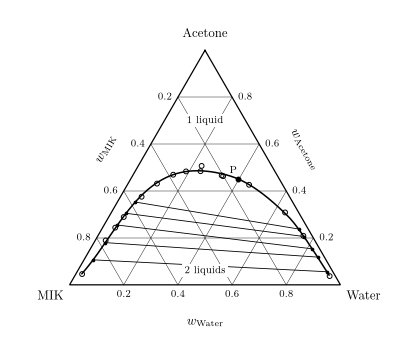

In [8]:
# --- Print art: Figure 11.2-8 ----------------------------------------------
#   pdf/Figure_11.2-8.pdf -> deliverables/figures/print-bw/ch11/c11f011.pdf
#
# The dome is Othmer Table III; the five tie lines are Othmer Table VII. Both are
# measurements, and nothing on this figure is read off the printed art.
#
# Four drawing decisions, each forced by a gate rather than chosen:
#
# 1. 4.2 x 3.9 in. At 3.6 x 3.3 the label check below FAILS -- the 0.6 tick on the
#    right edge runs into the w_Acetone edge label. More room or a shorter name; never
#    smaller type. Nothing in printed art goes below 7 pt. [[no-figure-text-below-7pt]]
#
# 2. corner_values=False: the "1" at each corner is redundant beside a named corner,
#    and at the two lower corners it lands on the measured points themselves.
#
# 3. The binodal is a SMOOTHING FIT, not an interpolation, and the reason is in the cell
#    that builds it: forcing a curve through all sixteen points turns through 104 deg at
#    the crest, because one measurement near the plait point sits 2.3 wt % above the
#    other fifteen. Fitting takes that to 1.4 deg. All sixteen points are plotted.
#
# 4. minors=1, and the grid is BLACK. The first version used thermo.charts' gray grid
#    and tools/check_print_art.py rejected the figure on `0.7 G` / `0.87 G`: gray needs
#    an author-granted waiver and this had none. [[black-not-gray]] says separate by
#    weight, not tint -- so the grid is 0.30 pt black against a 1.1 pt binodal. At full
#    minor density a black lattice competes with the data, so the minors come out.

# `smooth` is the FITTED curve built in the ordering cell. An earlier draft rebuilt it
# here as a PCHIP interpolation through the points, one line above the plot call, so the
# figure drew an interpolation while the tie lines and P were placed on the fit -- two
# different curves in one picture. The assert is here so that cannot come back silently.
assert len(smooth) == 400 and abs(_fit(smooth[0, 1] * 100) - smooth[0, 0] * 100) < 1e-6, \
    'smooth is not the fitted curve -- something rebuilt it'

fig, ax = plt.subplots(figsize=(4.2, 3.9))
ternary.ternary_axes(ax, top="Acetone", left="MIK", right="Water", symbol="w",
                     corner_values=False, minors=1)
ternary.plot(ax, smooth)
ternary.scatter(ax, curve)
for _I, _II in TIES:
    ternary.tie_line(ax, _I, _II)
# point() forwards **kw to the MARKER, not to its label, so a bbox cannot be passed
# through it. The label is kept clear of the grid by placing it, not by masking.
ternary.point(ax, PLAIT, "P", offset=(-0.030, 0.014))

# A region label sits in open space, which on a ruled diagram means it sits on a
# ruling. Mask the grid behind it rather than moving it -- where these two go is the
# whole point of them.
# zorder above the tie lines, or the mask is painted over by them.
mask = dict(bbox=dict(facecolor="w", edgecolor="none", pad=1.5), zorder=7)
ternary.region_label(ax, [(0.06, 0.47, 0.47)], "2 liquids", **mask)
ternary.region_label(ax, [(0.70, 0.15, 0.15)], "1 liquid", **mask)

# check_labels RAISES on an overlap; reaching the next line is the pass.
ternary.check_labels(ax)
print("  label check: no collisions")

os.makedirs("pdf", exist_ok=True)
fig.tight_layout()
fig.savefig("pdf/Figure_11.2-8.pdf", dpi=300, bbox_inches="tight")
print("  wrote pdf/Figure_11.2-8.pdf")

## Figure 11.2-10 — the same dome without the triangle

Two of the three weight fractions are independent, so the triangle is a convenience and
not a necessity. Plot MIK against acetone on ordinary square axes and the third
composition is one subtraction away, which is what the caption means by *"the water
weight fraction is obtained by difference."* The dome, the five tie lines and the sixteen
measurements are the same objects as in Fig. 11.2-8; only the projection changes.

Three things this view shows that the triangle does not:

- **The physical boundary is a straight line.** Water cannot be negative, so every
  mixture lies below $w_{\rm MIK} + w_{\rm Acetone} = 1$, drawn dashed. In the triangle
  that bound is an edge and disappears into the frame.
- **The errant measurement stands out.** 50.7 wt % acetone against 25.9 wt % MIK is the
  point sitting to the right of the curve near the middle of the figure, off it by about
  2 wt %.
- **The dome does not close.** Othmer's sixteen determinations stop at 4.6 and 3.7 wt %
  acetone, short of the acetone-free edge, where the curve would end at the mutual
  solubilities of MIK and water. Those two numbers are not in his Table III, so the curve
  is left open rather than closed with a segment nobody measured. The printed art closes the
  region with a shaded left boundary.

The printed art also fills the two-phase region with a gray tint. Printed art in this edition is
pure black ink, and the tie lines mark the region instead: a tie line exists only where
two phases do.


  water by difference reproduces all sixteen measured water contents (largest error 1.1e-16)
  at the crest the diagram reads 48.6 wt % acetone / 28.6 wt % MIK, so 22.8 wt % water
  '$w_{\\mathrm{Water}} = 0$' clears the nearest drawn line by 0.124 in composition units



  wrote pdf/Figure_11.2-10.pdf


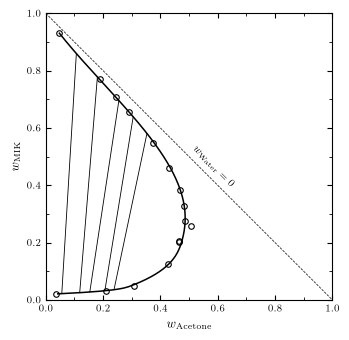

In [9]:
# --- Print art: Figure 11.2-10 ---------------------------------------------
#   pdf/Figure_11.2-10.pdf -> deliverables/figures/print-bw/ch11/c11f013.pdf
#
# The same dome, the same tie lines, rectangular axes. Compositions here are
# (acetone, MIK, water), so columns 0 and 1 are already x and y in that order --
# reversing them is the silent error this projection invites, and the gate below
# catches it by testing that the drawn points close on the measured water contents.
#
# No region labels, and that is a measurement rather than a preference: "2 liquids"
# occupies 0.13 of the x axis at 8 pt, and every position inside the dome is within
# 0.03 of a tie line or of the binodal, so the label would sit on the data. The
# triangular figure has room for it; this one does not.
_dome_xy = smooth[:, :2]                     # x = acetone, y = MIK, on the fitted curve
_pts_xy = curve[:, :2]                       # the sixteen measurements, same order

# The projection is only honest if the third composition is recoverable, so check it:
# water by difference must reproduce the measured water column.
_water_by_difference = 1 - _pts_xy.sum(axis=1)
assert np.allclose(_water_by_difference, curve[:, 2], atol=1e-12), \
    "water by difference does not reproduce the data -- the two columns are swapped"
print(f"  water by difference reproduces all sixteen measured water contents"
      f" (largest error {np.abs(_water_by_difference - curve[:, 2]).max():.1e})")
print(f"  at the crest the diagram reads {100*_dome_xy[np.argmax(_dome_xy[:, 0]), 0]:.1f} wt %"
      f" acetone / {100*_dome_xy[np.argmax(_dome_xy[:, 0]), 1]:.1f} wt % MIK, so"
      f" {100*(1 - _dome_xy[np.argmax(_dome_xy[:, 0])].sum()):.1f} wt % water")

fig10, ax10 = plt.subplots(figsize=(3.6, 3.5))
ax10.plot([0, 1], [1, 0], "--", color="k", lw=0.5)          # water = 0, the physical bound
ax10.plot(_dome_xy[:, 0], _dome_xy[:, 1], "-", color="k", lw=1.1)
ax10.plot(_pts_xy[:, 0], _pts_xy[:, 1], "o", color="k", ms=4, mfc="none", mew=0.8)
for _I, _II in TIES:
    ax10.plot([_I[0], _II[0]], [_I[1], _II[1]], "-", color="k", lw=0.6)
ax10.text(0.575, 0.455, r"$w_{\mathrm{Water}} = 0$", size=7, rotation=-45,
          rotation_mode="anchor", ha="center", va="bottom")
ax10.set_xlim(0, 1)
ax10.set_ylim(0, 1)
ax10.set_xticks(np.arange(0, 1.01, 0.2)); ax10.set_xticks(np.arange(0, 1.01, 0.1), minor=True)
ax10.set_yticks(np.arange(0, 1.01, 0.2)); ax10.set_yticks(np.arange(0, 1.01, 0.1), minor=True)
ax10.set_xlabel(r"$w_{\mathrm{Acetone}}$", size=9)
ax10.set_ylabel(r"$w_{\mathrm{MIK}}$", size=9)
ax10.tick_params(labelsize=7, direction="in", which="both", top=True, right=True)
ax10.set_aspect("equal")

# The one label on the figure names the dashed line, so it has to clear the data.
ternary.check_labels(ax10)
_drawn = np.vstack([_dome_xy] + [np.array([[I[0], I[1]], [II[0], II[1]]]) for I, II in TIES])
for _t in ax10.texts:
    _d = np.hypot(*(_drawn - np.array(_t.get_position())).T).min()
    print(f"  {_t.get_text()!r} clears the nearest drawn line by {_d:.3f} in composition units")
    assert _d > 0.04, "a label is sitting on the data"

fig10.tight_layout()
fig10.savefig("pdf/Figure_11.2-10.pdf", dpi=300, bbox_inches="tight")
print("\n  wrote pdf/Figure_11.2-10.pdf")


## The illustration, step 1: where does the combined feed sit?

Three kilograms of MIK are contacted with one kilogram of a 60 % acetone / 40 % water
mixture. Before any equilibrium is considered, the two streams are simply added — and
*that* is the composition that has to be located on the diagram.

In [10]:
solvent = (1.0, 0.0, 0.0)          # pure MIK
aqueous = (0.0, 0.6, 0.4)          # the acetone-water mixture to be treated

total, z = mix_streams([3.0, 1.0], [solvent, aqueous])
print(f"  combined feed: {total:.1f} kg at "
      f"{100*z[MIK]:.0f} wt % MIK, {100*z[ACE]:.0f} wt % acetone, {100*z[WAT]:.0f} wt % water")
print("  SIS:           4.0 kg at 75 wt % MIK, 15 wt % acetone, 10 wt % water")

  combined feed: 4.0 kg at 75 wt % MIK, 15 wt % acetone, 10 wt % water
  SIS:           4.0 kg at 75 wt % MIK, 15 wt % acetone, 10 wt % water


## Step 2: the tie line — and where the illustration's numbers came from

The illustration reports the two phases as

| | MIK | acetone | water |
|---|---|---|---|
| MIK-rich | 80.5 | 15.5 | 4.0 |
| water-rich | 2.0 | 8.0 | 90.0 |

and says only that they follow from "the tie line through this feed point." There is no
tie line in the printed data, so these two compositions were read off the figure with a
straightedge.

**That can be checked, even without Othmer's tie-line table.** Whatever the tie line
is, both of its ends must lie *on the measured coexistence curve* — and the curve is the
one piece of this that is a measurement. So the read-off compositions can be tested
against the dome directly.

In [11]:
SIS_MIK_RICH   = np.array([80.5, 15.5,  4.0]) / 100
SIS_WATER_RICH = np.array([ 2.0,  8.0, 90.0]) / 100

def distance_to_binodal(comp):
    """Shortest distance, in the plane of the diagram, from `comp` to the curve."""
    p = ternary.to_xy(np.asarray(comp)[[ACE, MIK, WAT]]).ravel()
    return np.hypot(*(ternary.to_xy(smooth) - p).T).min()

print(f"  {'phase':12s} {'MIK':>6s} {'acetone':>8s} {'water':>7s}   distance to the curve")
for name, c in (("MIK-rich", SIS_MIK_RICH), ("water-rich", SIS_WATER_RICH)):
    print(f"  {name:12s} {100*c[MIK]:6.1f} {100*c[ACE]:8.1f} {100*c[WAT]:7.1f}"
          f"   {100*distance_to_binodal(c):5.2f} wt %")

print("\n  For scale: the sixteen measured points are spaced 3 to 12 wt % apart along")
print("  the curve, so a read-off end landing within ~1 wt % of it is as good as the")
print("  data can resolve -- and one landing much further off is a straightedge error,")
print("  not a measurement.")

  phase           MIK  acetone   water   distance to the curve
  MIK-rich       80.5     15.5     4.0    0.04 wt %
  water-rich      2.0      8.0    90.0    0.93 wt %

  For scale: the sixteen measured points are spaced 3 to 12 wt % apart along
  the curve, so a read-off end landing within ~1 wt % of it is as good as the
  data can resolve -- and one landing much further off is a straightedge error,
  not a measurement.


## What the straightedge cost

The chapter reads three tie lines off Figure 11.2-8 — one in Illustration 11.2-8 and two in
Illustration 11.2-9 — and they can now be compared with the measurements they were read from.
For each, interpolate Othmer's distribution at the MIK-rich acetone content the chapter used,
and ask what acetone the water-rich phase should then hold.


In [12]:
READ_OFF = [("Ill. 11.2-8",           15.5,  8.0),
            ("Ill. 11.2-9, stage 1",  32.0, 23.0),
            ("Ill. 11.2-9, stage 2",   7.6,  3.0)]

lo, hi = 100 * TABLE_VII[0, 0], 100 * TABLE_VII[-1, 0]
print(f"  Othmer's five pairs span {lo:.2f} to {hi:.1f} wt % acetone in the MIK phase.\n")
print(f"  {'':22s} {'acetone in MIK':>15s} {'water phase':>12s} {'Othmer':>8s} {'diff':>7s}")
for name, aS, aW in READ_OFF:
    if not (lo <= aS <= hi):
        print(f"  {name:22s} {aS:12.1f} wt % {aW:10.1f} {'--':>8s} {'--':>7s}"
              f"   below the lowest measured pair")
        continue
    # np.interp CLAMPS outside its range rather than extrapolating, which is why the
    # out-of-range case is refused above instead of being given a number that looks
    # like a comparison and is not one.
    othmer = np.interp(aS / 100, TABLE_VII[:, 0], TABLE_VII[:, 1]) * 100
    print(f"  {name:22s} {aS:12.1f} wt % {aW:10.1f} {othmer:8.1f} {aW - othmer:+7.1f}")

print("\n  Where the comparison can be made, the chapter's read-off tie lines sit 0.7 and")
print("  1.7 wt % acetone from the measured distribution. For compositions lifted off a")
print("  printed diagram with a straightedge that is close -- and it is also the size of")
print("  the uncertainty the illustrations carry without saying so.")
print("\n  Illustration 11.2-9's second stage is the interesting one: its tie line lies")
print("  BELOW everything Othmer measured, in the dilute corner where the extraction is")
print("  hardest and the tie lines are shortest. The chapter is extrapolating there, and")
print("  the notebook will not pretend otherwise by clamping to the nearest pair.")


  Othmer's five pairs span 10.66 to 35.3 wt % acetone in the MIK phase.

                          acetone in MIK  water phase   Othmer    diff
  Ill. 11.2-8                    15.5 wt %        8.0      9.7    -1.7
  Ill. 11.2-9, stage 1           32.0 wt %       23.0     21.6    +1.4
  Ill. 11.2-9, stage 2            7.6 wt %        3.0       --      --   below the lowest measured pair

  Where the comparison can be made, the chapter's read-off tie lines sit 0.7 and
  1.7 wt % acetone from the measured distribution. For compositions lifted off a
  printed diagram with a straightedge that is close -- and it is also the size of
  the uncertainty the illustrations carry without saying so.

  Illustration 11.2-9's second stage is the interesting one: its tie line lies
  BELOW everything Othmer measured, in the dilute corner where the extraction is
  hardest and the tie lines are shortest. The chapter is extrapolating there, and
  the notebook will not pretend otherwise by clamping to the 

## Step 3: the lever rule

With the feed on the tie line and both ends known, the amounts follow from mass balance
alone — no thermodynamics left in it. SIS balances on water and gets
$L^{\rm I} = 3.721$ and $L^{\rm II} = 0.279$ kg.

**`tie_line_split` deliberately does not balance on one species.** It solves all
three by least squares and reports the residual, because with compositions read off a
diagram by eye the three balances do not agree, and *which species you pick moves the
answer*. The illustration does not say that it made a choice.

In [13]:
LI, LII = tie_line_split(z, SIS_MIK_RICH, SIS_WATER_RICH, total=total)
print(f"  least squares over all three species:  L_I = {LI:.3f} kg   L_II = {LII:.3f} kg")
print(f"  SIS, balancing on water:               L_I = 3.721 kg   L_II = 0.279 kg")

print("\n  what each single-species balance would have given on its own:")
for k, name in ((MIK, "MIK"), (ACE, "acetone"), (WAT, "water")):
    one = total * (z[k] - SIS_WATER_RICH[k]) / (SIS_MIK_RICH[k] - SIS_WATER_RICH[k])
    print(f"    {name:8s} L_I = {one:.3f} kg")

  least squares over all three species:  L_I = 3.720 kg   L_II = 0.280 kg
  SIS, balancing on water:               L_I = 3.721 kg   L_II = 0.279 kg

  what each single-species balance would have given on its own:
    MIK      L_I = 3.720 kg
    acetone  L_I = 3.733 kg
    water    L_I = 3.721 kg


In [14]:
print(f"  {'':12s} {'MIK':>8s} {'acetone':>9s} {'water':>8s}")
for name, L, c in (("MIK-rich", LI, SIS_MIK_RICH), ("water-rich", LII, SIS_WATER_RICH)):
    kg = L * c
    print(f"  {name:12s} " + " ".join(f"{v:8.3f}" for v in kg))

kg_total = LI * SIS_MIK_RICH + LII * SIS_WATER_RICH
print(f"  {'sum':12s} " + " ".join(f"{v:8.3f}" for v in kg_total))
print(f"  {'fed':12s} " + " ".join(f"{v:8.3f}" for v in total * z))

recovered = LI * SIS_MIK_RICH[ACE] / (total * z[ACE])
print(f"\n  acetone into the MIK phase: {100*recovered:.1f} % of what was fed")
print(f"  MIK used per kg of acetone recovered: {3.0 / (LI * SIS_MIK_RICH[ACE]):.1f} kg")

                    MIK   acetone    water
  MIK-rich        2.995    0.577    0.149
  water-rich      0.006    0.022    0.252
  sum             3.001    0.599    0.400
  fed             3.000    0.600    0.400

  acetone into the MIK phase: 96.1 % of what was fed
  MIK used per kg of acetone recovered: 5.2 kg


## What the single stage actually costs

The extraction works: most of the acetone ends up in the MIK phase. But look at what it
took — 3 kg of solvent for 1 kg of feed, to recover about half a kilogram of acetone.
The solvent now has to be separated from the acetone by distillation, and that is a
second separation costing more than the first.

This is why the chapter goes straight on to a staged process in Illustration 11.2-9,
and it is the argument for every countercurrent extractor in a plant: the same recovery
with less solvent, paid for in equipment instead of in energy.

## Your turn

1. Move the feed. Contact 2 kg of MIK with the same 1 kg of feed instead of 3 kg — where
   does the combined composition land, and is it still inside the dome? Find the smallest
   amount of MIK that still gives two phases, and mark that point on the diagram.
2. The read-off tie line is the weakest number in the illustration. Shift the water-rich
   end along the curve by 2 wt % in acetone and re-solve. How much do $L^{\rm I}$ and
   $L^{\rm II}$ move? That sensitivity is the case for measured tie lines.
3. Both ends of the tie line should sit on the dome. Project the illustration's two
   compositions onto the measured curve, re-solve with the projected pair, and compare.
4. Draw the diagram in **mole** fractions instead of weight fractions, using molar
   masses 100.16 (MIK), 58.08 (acetone) and 18.02 (water). The dome changes shape.
   Footnote 12 warns that Aspen draws this diagram in mole fractions and the chapter
   works in weight fractions, "and therefore not directly comparable" — this is that
   sentence, made into a picture.